# 4.10.1 Data Security Risks & Data Preparation

## Table of Contents
##### 1. Importing Data
##### 2. Addressing Data Security Risks
##### 3. Data preparation: Importing wrangled departments data to use for customer profiling
##### 3.1. Regional segmentation of the Data (by state)
##### 3.2. Spending habits between different U.S. regions
##### 4. Low-activity customers exclusion

## 1. Importing libraries and data

In [3]:
# Importing libraries

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [4]:
# Creating main path

path = r'/Users/helenarobalinho/Desktop/Data Analytics/2. Data Immersion/Achievement 4 - Python Fundamentals for Data Analysts/03-2026 Instacart Basket Analysis'

In [5]:
# Importing the final_merged data

final_merged = pd.read_pickle(os.path.join(path, '02 Data', 'Prepared Data', 'final_merged.pkl'))

In [6]:
# Checking the shape

final_merged.shape

(32404859, 34)

In [7]:
# Quick check

final_merged.head()

,product_id,product_name,aisle_id,department_id,prices,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,...,order_frequency_flag,first_name,surname,gender,state,age,date_joined,n_dependents,fam_status,income
0,1,Chocolate Sandwich Cookies,61,19,5.8,3139998,138,28,6,11,...,Frequent customer,Charles,Cox,Male,Minnesota,81,8/1/2019,1,married,49620
1,1,Chocolate Sandwich Cookies,61,19,5.8,1977647,138,30,6,17,...,Frequent customer,Charles,Cox,Male,Minnesota,81,8/1/2019,1,married,49620
2,1,Chocolate Sandwich Cookies,61,19,5.8,389851,709,2,0,21,...,Frequent customer,Deborah,Glass,Female,Vermont,66,6/16/2018,2,married,158302
3,1,Chocolate Sandwich Cookies,61,19,5.8,652770,764,1,3,13,...,Frequent customer,Heather,Myers,Female,Wisconsin,40,2/9/2020,3,married,31308
4,1,Chocolate Sandwich Cookies,61,19,5.8,1813452,764,3,4,17,...,Frequent customer,Heather,Myers,Female,Wisconsin,40,2/9/2020,3,married,31308


## 2. Addressing Data Security Risks

PII (personally identifiable information) handling

In [8]:
# Checking columns for any data that could contain PII

final_merged.columns

Index(['product_id', 'product_name', 'aisle_id', 'department_id', 'prices',
       'order_id', 'user_id', 'order_number', 'orders_day_of_week',
       'order_hour_of_day', 'days_since_prior_order', 'First_order',
       'add_to_cart_order', 'reordered', '_merge', 'price_range_loc',
       'busiest_day', 'busiest_days', 'busiest_period_of_day', 'max_order',
       'loyalty_flag', 'avg_product_price', 'spending_flag',
       'median_days_between_orders', 'order_frequency_flag', 'first_name',
       'surname', 'gender', 'state', 'age', 'date_joined', 'n_dependents',
       'fam_status', 'income'],
      dtype='object')

- This dataset contains PII such as first_name and surname of customers.
- Paired with other sensitive data (age, location, gender), this could pose as a privacy risk.
- Therefore the columns 'first_name' and 'surname' will be dropped. They are not useful to the analysis and user_id can be used to identity customers instead. 

In [9]:
# Dropping columns that contain PII. I will overwrite, since names will not be used going foward. 

final_merged.drop(columns = ['first_name', 'surname'], axis = 1, inplace = True)

In [10]:
# Checking that columns were removed

final_merged.columns

Index(['product_id', 'product_name', 'aisle_id', 'department_id', 'prices',
       'order_id', 'user_id', 'order_number', 'orders_day_of_week',
       'order_hour_of_day', 'days_since_prior_order', 'First_order',
       'add_to_cart_order', 'reordered', '_merge', 'price_range_loc',
       'busiest_day', 'busiest_days', 'busiest_period_of_day', 'max_order',
       'loyalty_flag', 'avg_product_price', 'spending_flag',
       'median_days_between_orders', 'order_frequency_flag', 'gender', 'state',
       'age', 'date_joined', 'n_dependents', 'fam_status', 'income'],
      dtype='object')

In [11]:
# Checking the new shape

final_merged.shape

(32404859, 32)

First names and surnames were removed to reduce user-identification risk. Other customer attributes were retained as they are used for segmentation and are not direct identifiers in this context.

## 3. Data preparation: Importing wrangled departments data to use for customer profiling

In [12]:
# Importing wrangled departments data as a csv file

dept = pd.read_csv(os.path.join(path, '02 Data', 'Prepared Data','departments_wrangled.csv'), index_col = False)

In [13]:
# Checking the content

dept.head()

,Unnamed: 0,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [14]:
# Renaming the first column (should be the department_id)

dept.rename(columns = {'Unnamed: 0' : 'department_id'}, inplace = True)

In [15]:
# Checking the output

dept

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [16]:
# Creating a dictionary from the columns 'department_id' and 'department'

data_dict = dept.set_index('department_id')['department'].to_dict()

In [17]:
# Checking the dictionary

data_dict

{1: 'frozen',
 2: 'other',
 3: 'bakery',
 4: 'produce',
 5: 'alcohol',
 6: 'international',
 7: 'beverages',
 8: 'pets',
 9: 'dry goods pasta',
 10: 'bulk',
 11: 'personal care',
 12: 'meat seafood',
 13: 'pantry',
 14: 'breakfast',
 15: 'canned goods',
 16: 'dairy eggs',
 17: 'household',
 18: 'babies',
 19: 'snacks',
 20: 'deli',
 21: 'missing'}

In [18]:
# Apllying mapping to connect department_id with departement name

final_merged['department'] = final_merged['department_id'].map(data_dict)

In [ ]:
# Checking updated dataframe

final_merged.head()

In [20]:
# Checking shape of updated dataframe with the new column 'department'

final_merged.shape

(32404859, 33)

## 3.1. Regional segmentation of the Data

In order to compare customer behavior in different geographic areas, it will be created a regional segmentation of the data. 

It will be created a "Region" column based on the "State" column from the customers data. 

Regions will be based on the divisons outlined in following link: (https://simple.wikipedia.org/wiki/List_of_regions_of_the_United_States)


In [21]:
# Creating a dictionary mapping the states to regions 

state_to_region = {
    
    # Northeast
    'Maine': 'Northeast', 'New Hampshire': 'Northeast', 'Vermont': 'Northeast', 
    'Massachusetts': 'Northeast', 'Rhode Island': 'Northeast', 'Connecticut': 'Northeast', 
    'New York': 'Northeast', 'Pennsylvania': 'Northeast', 'New Jersey': 'Northeast',
    # Midwest
    'Wisconsin': 'Midwest', 'Michigan': 'Midwest', 'Illinois': 'Midwest', 
    'Indiana': 'Midwest', 'Ohio': 'Midwest', 'North Dakota': 'Midwest', 
    'South Dakota': 'Midwest', 'Nebraska': 'Midwest', 'Kansas': 'Midwest', 
    'Minnesota': 'Midwest', 'Iowa': 'Midwest', 'Missouri': 'Midwest',
    # South
    'Delaware': 'South', 'Maryland': 'South', 'District of Columbia': 'South', 
    'Virginia': 'South', 'West Virginia': 'South', 'North Carolina': 'South', 
    'South Carolina': 'South', 'Georgia': 'South', 'Florida': 'South', 
    'Kentucky': 'South', 'Tennessee': 'South', 'Mississippi': 'South', 
    'Alabama': 'South', 'Oklahoma': 'South', 'Texas': 'South', 
    'Arkansas': 'South', 'Louisiana': 'South',
    # West
    'Idaho': 'West', 'Montana': 'West', 'Wyoming': 'West', 'Nevada': 'West', 
    'Utah': 'West', 'Colorado': 'West', 'Arizona': 'West', 'New Mexico': 'West', 
    'Alaska': 'West', 'Washington': 'West', 'Oregon': 'West', 'California': 'West', 'Hawaii': 'West'
}

In [22]:
# Creating the 'region' column and assigning regions for each state

final_merged['region'] = final_merged['state'].map(state_to_region)

In [23]:
# Checking results of mapping

final_merged[['state', 'region']]

,state,region
0,Minnesota,Midwest
1,Minnesota,Midwest
2,Vermont,Northeast
3,Wisconsin,Midwest
4,Wisconsin,Midwest
...,...,...
32404854,Rhode Island,Northeast
32404855,West Virginia,South
32404856,Michigan,Midwest
32404857,Michigan,Midwest


In [24]:
# Checking the updated shape

final_merged.shape

(32404859, 34)

In [25]:
# Validating regional distribution

final_merged['region'].value_counts(dropna = False)

region
South        10791885
West          8292913
Midwest       7597325
Northeast     5722736
Name: count, dtype: int64

The south is Instacart's largest market, and the Northeast is the smallest market.

## 3.2. Spending habits between different U.S. regions

Let's create a crosstab between the region and the spending_flag.

In [26]:
# Creating a crosstab of the 'region' column with the 'spending_flag' column

crosstab_regional_spending = pd.crosstab(final_merged['region'], final_merged['spending_flag'], dropna = False)

In [27]:
# Checking the crosstab

crosstab_regional_spending

spending_flag,High spender,Low spender
region,,
Midwest,155975,7441350
Northeast,108225,5614511
South,209691,10582194
West,160354,8132559


In [28]:
# Copying crosstab to clipboard to open in Excel

crosstab_regional_spending.to_clipboard()

Text(0, 0.5, 'Count of Customers (in millions)')

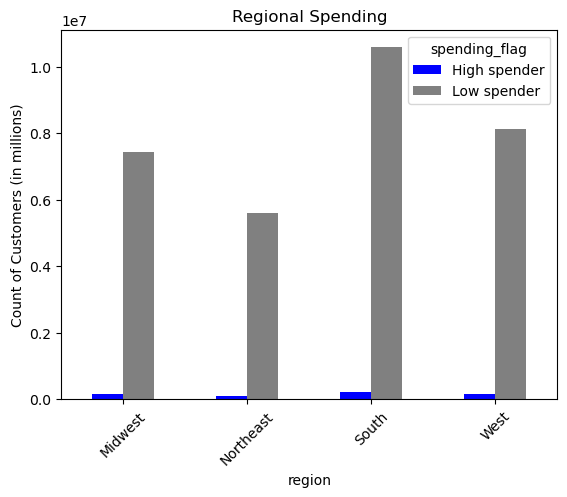

In [29]:
# Creating a bar chart to visualize crosstab_regional_spending

bar_regional_spending = crosstab_regional_spending.plot.bar(color = ['blue', 'grey'])

# Title 
plt.title ('Regional Spending')

# Rotating labels for better readability 
plt.xticks(rotation=45)

# Y-axis label is in scientific notation (1e7 is actually 10 million)
plt.ylabel ('Count of Customers (in millions)')

Most customers are considered low spenders in all regions.

All of the four regions seem to follow a low frequency of high spending customer behavior, meaning there is no visible difference in spending habits between the regions.

In [30]:
# Exporting the bar chart

bar_regional_spending.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_regional_spending.png'))

## 4. Low-activity customers exclusion

Customers with less than 5 orders are considered 'low-activity' and they will be flagged and excluded from a CFO-level analysis. This step removes low-engagement users that generate minimal revenue, in order to focus on economically meaningfull customers.

In [31]:
# Creating an exclusion flag column based on the 'max_order' column

final_merged.loc[final_merged['max_order'] >= 5, 'customer_activity'] = 'High'
final_merged.loc[final_merged['max_order'] < 5, 'customer_activity'] = 'Low'

In [32]:
# Checking flag count

final_merged['customer_activity'].value_counts(dropna = False)

customer_activity
High    30964564
Low      1440295
Name: count, dtype: int64

In [33]:
# Creating a new dataframe (subset) of only the low-activity customers

low_activity_users = final_merged [final_merged ['customer_activity'] == 'Low']

In [34]:
# Checking the low_activity_users subset

low_activity_users.head()

,product_id,product_name,aisle_id,department_id,prices,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,...,gender,state,age,date_joined,n_dependents,fam_status,income,department,region,customer_activity
3,1,Chocolate Sandwich Cookies,61,19,5.8,652770,764,1,3,13,...,Female,Wisconsin,40,2/9/2020,3,married,31308,snacks,Midwest,Low
4,1,Chocolate Sandwich Cookies,61,19,5.8,1813452,764,3,4,17,...,Female,Wisconsin,40,2/9/2020,3,married,31308,snacks,Midwest,Low
34,1,Chocolate Sandwich Cookies,61,19,5.8,2434812,1598,1,2,12,...,Male,Kansas,41,1/7/2018,2,married,122060,snacks,Midwest,Low
35,1,Chocolate Sandwich Cookies,61,19,5.8,1531889,1598,2,2,10,...,Male,Kansas,41,1/7/2018,2,married,122060,snacks,Midwest,Low
36,1,Chocolate Sandwich Cookies,61,19,5.8,726947,1598,3,4,17,...,Male,Kansas,41,1/7/2018,2,married,122060,snacks,Midwest,Low


In [35]:
# Checking the shape of the low_activity_users subset

low_activity_users.shape

(1440295, 35)

In [36]:
# Exporting this subset

low_activity_users.to_pickle(os.path.join(path, '02 Data', 'Prepared Data', 'low_activity_users.pkl'))

### Excluding the low-activity customers from the data

In [37]:
# Creating a new dataframe df_final with only high-activity customers included

df_final = final_merged[final_merged['customer_activity']== 'High']

In [38]:
# Checking shape of updated df

df_final.shape

(30964564, 35)

In [39]:
# Checking the df

df_final.head()

,product_id,product_name,aisle_id,department_id,prices,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,...,gender,state,age,date_joined,n_dependents,fam_status,income,department,region,customer_activity
0,1,Chocolate Sandwich Cookies,61,19,5.8,3139998,138,28,6,11,...,Male,Minnesota,81,8/1/2019,1,married,49620,snacks,Midwest,High
1,1,Chocolate Sandwich Cookies,61,19,5.8,1977647,138,30,6,17,...,Male,Minnesota,81,8/1/2019,1,married,49620,snacks,Midwest,High
2,1,Chocolate Sandwich Cookies,61,19,5.8,389851,709,2,0,21,...,Female,Vermont,66,6/16/2018,2,married,158302,snacks,Northeast,High
5,1,Chocolate Sandwich Cookies,61,19,5.8,1701441,777,16,1,7,...,Female,Hawaii,51,1/4/2019,2,married,57797,snacks,West,High
6,1,Chocolate Sandwich Cookies,61,19,5.8,1871483,825,3,2,14,...,Male,District of Columbia,20,5/8/2019,3,living with parents and siblings,34171,snacks,South,High


## Exporting the updated dataframe df_final (only high-activity customers) to use for final analyses

In [40]:
# Exporting updated dataframe as a pickle (with department name, regions, and customer activity columns - no PII columns)

df_final.to_pickle(os.path.join(path, '02 Data','Prepared Data', 'df_final.pkl'))